# Event & Trend Tracking: Analyzing Reddit's Reaction to Real-World Events
### LDA Topic Modeling

**Dataset:** `fddemarco/pushshift-reddit` — November 2016 (US Presidential Election)  
**Research Question:** How do Reddit communities react to major events, and can we detect these reactions through spikes in posts and topics?

## STEP 1 — Install Libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install gensim pyLDAvis nltk matplotlib seaborn tqdm huggingface_hub datasets pandas pyarrow
print('Libraries installed')

✅ All libraries installed



[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## STEP 2 — Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import re
import gc
import multiprocessing
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm.auto import tqdm
from huggingface_hub import hf_hub_download

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim import corpora
from gensim.models import LdaMulticore, CoherenceModel
from gensim.models.phrases import Phrases, Phraser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Detect CPU cores automatically
TOTAL_CORES  = multiprocessing.cpu_count()
WORKER_CORES = TOTAL_CORES - 2               # leave 2 free for OS tasks = 14

print(f'Imports successful')
print(f'   Detected {TOTAL_CORES} logical processors')
print(f'   LDA will use {WORKER_CORES} worker cores')

✅ All imports successful
   Detected 16 logical processors
   LDA will use 14 worker cores


## STEP 3 — Configuration

In [ ]:
# CONFIGURATION

# Data size
SAMPLE_SIZE  = 300_000
RANDOM_STATE = 42

# LDA parameters
NUM_TOPICS   = 20
PASSES       = 15
CHUNKSIZE    = 8000

# Vocabulary filtering
NO_BELOW     = 15
NO_ABOVE     = 0.4

# Spike detection
SPIKE_Z_THRESHOLD = 2.0

# Time resampling
TIME_FREQ    = 'D'

# Output folder
import os
OUTPUT_DIR = './lda_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

#
print('Configuration set')
print(f'   Sample size  : {SAMPLE_SIZE:,} posts')
print(f'   Topics       : {NUM_TOPICS}')
print(f'   Passes       : {PASSES}')
print(f'   Worker cores : {WORKER_CORES}')
print(f'   Output dir   : {OUTPUT_DIR}')

✅ Configuration set
   Sample size  : 300,000 posts
   Topics       : 20
   Passes       : 15
   Worker cores : 14
   Output dir   : ./lda_outputs


## STEP 4 — Load Data
Downloads **November 2016** from Hugging Face.

In [ ]:
print('Downloading RS_2016-11_00.parquet from Hugging Face...')
print('Note: File is cached after first download\n')

local_path = hf_hub_download(
    repo_id   = 'fddemarco/pushshift-reddit',
    filename  = 'data/RS_2016-11_00.parquet',
    repo_type = 'dataset'
)
print(f'File cached at: {local_path}\n')

# Load all columns we need
df = pd.read_parquet(local_path, columns=[
    'id', 'title', 'selftext', 'subreddit',
    'author', 'created_utc', 'score', 'num_comments'
])
print(f'Raw file: {len(df):,} posts')

# Sample if file is larger than SAMPLE_SIZE
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    print(f'Sampled to {SAMPLE_SIZE:,} posts')
else:
    print(f'Using full file ({len(df):,} posts)')

# Combine title + selftext
df['selftext'] = df['selftext'].fillna('').replace(
    {'[deleted]': '', '[removed]': '', 'null': ''})
df['text'] = df['title'].fillna('') + ' ' + df['selftext']
df['text'] = df['text'].str.strip()

# Free columns we no longer need
df.drop(columns=['title', 'selftext'], inplace=True)
gc.collect()

# Parse timestamps
df['date'] = pd.to_datetime(df['created_utc'], unit='s', utc=True, errors='coerce')

# Drop bad rows
df = df[df['text'].str.len() >= 20]
df = df[df['date'].notna()]
df = df.sort_values('date').reset_index(drop=True)

# Save checkpoint
df.to_pickle(f'{OUTPUT_DIR}/df_checkpoint.pkl')

print(f'\nLoaded {len(df):,} posts')
print(f'   Date range : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'   Subreddits : {df["subreddit"].nunique():,} unique')
print(f'   RAM usage  : ~{df.memory_usage(deep=True).sum() / 1e6:.0f} MB')
print(f'   Saved from   : {OUTPUT_DIR}/df_checkpoint.pkl')
df.head(3)

Note: File is cached after first download — future runs are instant

File cached at: C:\Users\rayhan\.cache\huggingface\hub\datasets--fddemarco--pushshift-reddit\snapshots\ce05aed1bdb821a06699f40ad5f91e2a3590b4ee\data\RS_2016-11_00.parquet

Raw file: 8,608,882 posts
Sampled to 300,000 posts

✅ Loaded 260,337 posts
   Date range : 2016-11-01 → 2016-11-30
   Subreddits : 23,118 unique
   RAM usage  : ~147 MB
   Saved to   : ./lda_outputs/df_checkpoint.pkl


,id,subreddit,author,created_utc,score,num_comments,text,date
0,5afz2w,DnD,Howlett2235,1477958401,20,7,my cat dmd our most recent session resulted in...,2016-11-01 00:00:01+00:00
1,5afz38,pokemontrades,Begiant,1477958404,1,3,ft 6 na volc codes lf event offers with proof ...,2016-11-01 00:00:04+00:00
2,5afz3o,abetterworldnews,abwnbot,1477958407,1,1,millionaires to run nearly half of brazils top...,2016-11-01 00:00:07+00:00


## STEP 5 — Exploratory Data Analysis

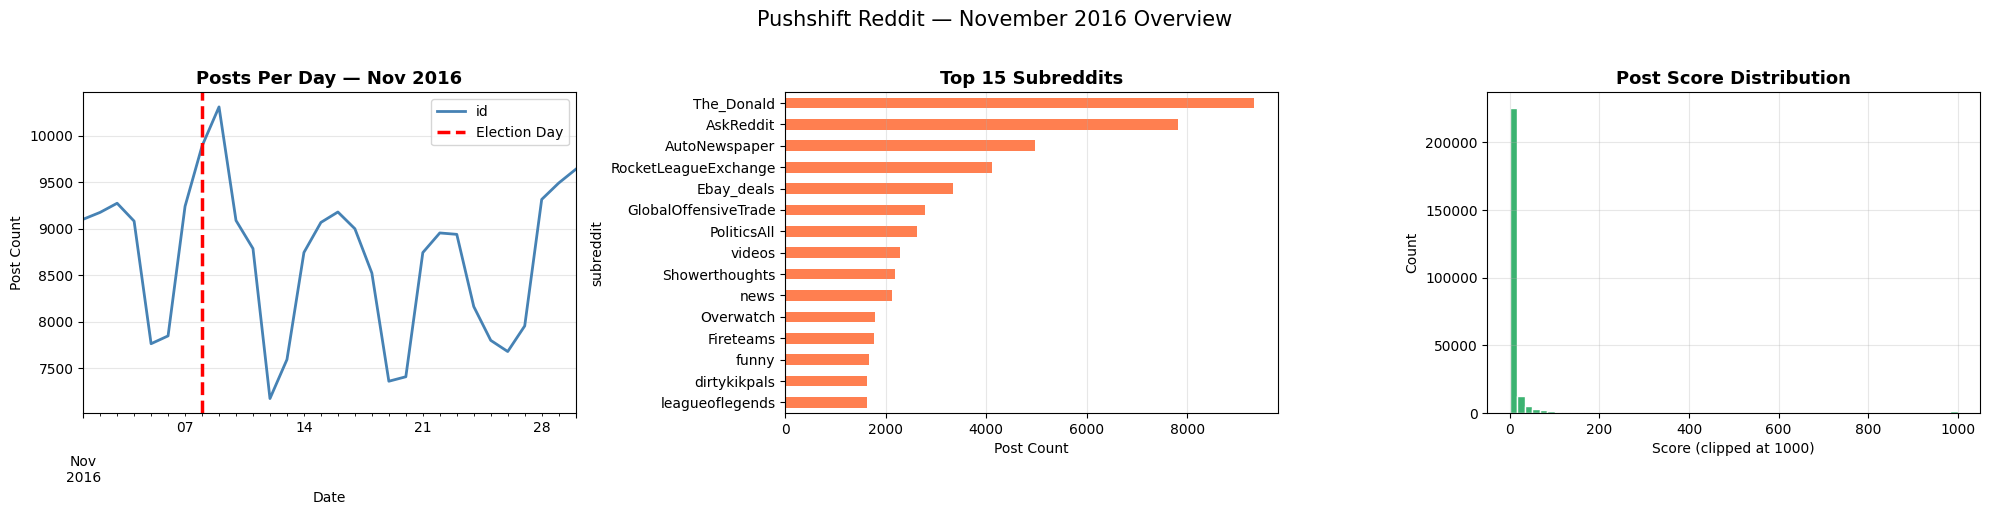

Total posts  : 260,337
Peak day     : 2016-11-09 (10,310 posts)
Avg score    : 42.1

✅ Saved → ./lda_outputs/eda_overview.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Posts per day
daily = df.set_index('date').resample('D')['id'].count()
daily.plot(ax=axes[0], color='steelblue', linewidth=2)
axes[0].axvline(pd.Timestamp('2016-11-08', tz='UTC'),
                color='red', linestyle='--', linewidth=2.5, label='Election Day')
axes[0].set_title('Posts Per Day — Nov 2016', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Post Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top subreddits
top_subs = df['subreddit'].value_counts().head(15)
top_subs.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Subreddits', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Post Count')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# Score distribution
df['score'].clip(upper=1000).hist(ax=axes[2], bins=60,
                                   color='mediumseagreen', edgecolor='white')
axes[2].set_title('Post Score Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Score (clipped at 1000)')
axes[2].set_ylabel('Count')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Pushshift Reddit — November 2016 Overview', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total posts  : {len(df):,}')
print(f'Peak day     : {daily.idxmax().date()} ({daily.max():,} posts)')
print(f'Avg score    : {df["score"].mean():.1f}')
print(f'Saved → {OUTPUT_DIR}/eda_overview.png')

## STEP 6 — Text Preprocessing
Cleans raw Reddit text before LDA training.

In [ ]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS  = set(stopwords.words('english'))
STOP_WORDS.update({
    # Reddit-specific noise
    'reddit', 'post', 'comment', 'upvote', 'downvote', 'edit', 'deleted',
    'removed', 'mod', 'subreddit', 'thread', 'amp', 'http', 'https', 'www',
    'com', 'net', 'org', 'gt', 'lt',
    # Generic words with no topical signal
    'like', 'just', 'get', 'also', 'would', 'could', 'really', 'even',
    'much', 'many', 'one', 'people', 'think', 'know', 'thing', 'lot',
    'way', 'time', 'make', 'want', 'good', 'need', 'use', 'see', 'say',
    'go', 'come', 'new', 'year', 'day', 'said', 'going', 'got', 'still',
    'back', 'well', 'never', 'every', 'right', 'first', 'last', 'long',
    'great', 'little', 'own', 'old', 'big', 'high', 'different', 'small',
    'large', 'next', 'early', 'young', 'public', 'bad', 'same', 'able'
})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # URLs
    text = re.sub(r'/?u/\w+', '', text)           # User mentions
    text = re.sub(r'/?r/\w+', '', text)           # Subreddit links
    text = re.sub(r'[^a-z\s]', ' ', text)         # Letters only
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text):
    return [
        lemmatizer.lemmatize(t)
        for t in clean_text(text).split()
        if t not in STOP_WORDS and len(t) > 2
    ]

print('Tokenizing posts...')
df['tokens'] = [tokenize(t) for t in tqdm(df['text'], desc='Tokenizing')]

before = len(df)
df = df[df['tokens'].map(len) >= 5].reset_index(drop=True)
print(f'\nRemoved {before - len(df):,} near-empty posts. Remaining: {len(df):,}')

# Build bigrams
print('\nBuilding bigrams (e.g. donald+trump → donald_trump)...')
print('\nBuilding bigrams...')
bigram_phraser = Phraser(bigram_model)
df['tokens_bigram'] = [bigram_phraser[toks] for toks in tqdm(df['tokens'], desc='Applying bigrams')]

# Show top detected bigrams
from collections import Counter
all_bigrams = [t for toks in df['tokens_bigram'] for t in toks if '_' in t]
top_bigrams = Counter(all_bigrams).most_common(20)
print(f'\nTop 20 detected bigrams:')
print(', '.join(f'{b}({c})' for b, c in top_bigrams))
print('\nPreprocessing complete')

Tokenizing posts...
(Your Ryzen 9 will process this much faster than Colab)


Tokenizing:   0%|          | 0/260337 [00:00<?, ?it/s]


Removed 73,512 near-empty posts. Remaining: 186,825

Building bigrams (e.g. donald+trump → donald_trump)...


Applying bigrams:   0%|          | 0/186825 [00:00<?, ?it/s]


Top 20 detected bigrams:
support_since(2517), donald_trump(2273), biastrump_post(2096), anyone_else(2084), black_friday(1058), hillary_clinton(937), year_ago(928), month_ago(788), thanks_advance(636), sky_blue(600), forest_green(568), title_say(483), miami_herald(472), social_medium(457), united_state(439), greatly_appreciated(437), power_supply(421), biashillary_post(416), trump_supporter(391), white_house(381)

✅ Preprocessing complete


## STEP 7 — Build Dictionary & Corpus
Converts text into numbers that LDA can process.

In [ ]:
print('Building dictionary...')
dictionary = corpora.Dictionary(df['tokens_bigram'])
print(f'Vocabulary before filtering: {len(dictionary):,} unique words')

# Filter rare and overly common words
dictionary.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE)
dictionary.compactify()
print(f'Vocabulary after  filtering: {len(dictionary):,} unique words')

print('\nBuilding corpus (bag-of-words)...')
corpus = [dictionary.doc2bow(toks) for toks in tqdm(df['tokens_bigram'], desc='Building corpus')]

# Save corpus and dictionary
dictionary.save(f'{OUTPUT_DIR}/lda_dictionary')
corpora.MmCorpus.serialize(f'{OUTPUT_DIR}/lda_corpus.mm', corpus)

print(f'\nReady to train')
print(f'   Corpus      : {len(corpus):,} documents')
print(f'   Vocabulary  : {len(dictionary):,} words')
print(f'   Saved to    : {OUTPUT_DIR}/')

Building dictionary...
Vocabulary before filtering: 311,004 unique words
Vocabulary after  filtering: 18,341 unique words
(Removed words appearing in <15 docs or >40% of docs)

Building corpus (bag-of-words)...


Building corpus:   0%|          | 0/186825 [00:00<?, ?it/s]


✅ Ready to train
   Corpus      : 186,825 documents
   Vocabulary  : 18,341 words
   Saved to    : ./lda_outputs/


## STEP 8 — Coherence Sweep (Find Best Number of Topics)

Testing 15 topic counts using 14 cores...


Coherence sweep:   0%|          | 0/15 [00:00<?, ?it/s]

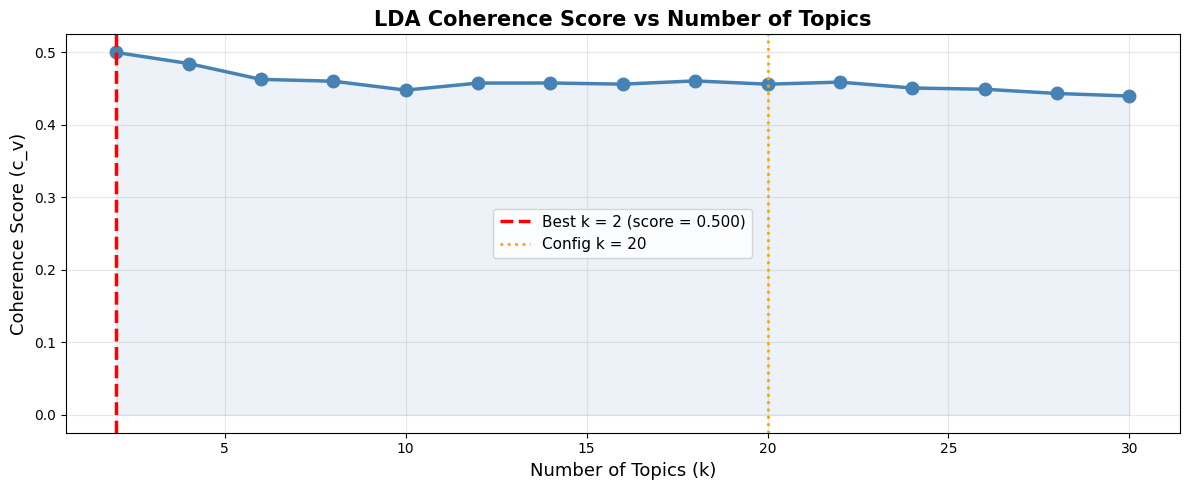


✅ Best number of topics: 2
   If 2 differs from NUM_TOPICS (20), update the config and retrain

All scores:
  k= 2  0.4995  ████████████████████████
  k= 4  0.4843  ████████████████████████
  k= 6  0.4624  ███████████████████████
  k= 8  0.4598  ██████████████████████
  k=10  0.4476  ██████████████████████
  k=12  0.4573  ██████████████████████
  k=14  0.4574  ██████████████████████
  k=16  0.4558  ██████████████████████
  k=18  0.4603  ███████████████████████
  k=20  0.4557  ██████████████████████
  k=22  0.4586  ██████████████████████
  k=24  0.4505  ██████████████████████
  k=26  0.4488  ██████████████████████
  k=28  0.4429  ██████████████████████
  k=30  0.4394  █████████████████████


In [ ]:
SKIP        = False
# Topic range to test
TOPIC_RANGE = range(2, 31, 2)   # Tests k = 2, 4, 6 ... 30

if not SKIP:
    coherence_scores = []
    print(f'Testing {len(list(TOPIC_RANGE))} topic counts using {WORKER_CORES} cores...')

    for k in tqdm(TOPIC_RANGE, desc='Coherence sweep'):
        m = LdaMulticore(
            corpus       = corpus,
            id2word      = dictionary,
            num_topics   = k,
            passes       = 3,
            workers      = WORKER_CORES,
            random_state = RANDOM_STATE,
            chunksize    = CHUNKSIZE
        )
        cm = CoherenceModel(
            model=m, texts=df['tokens_bigram'].tolist(),
            dictionary=dictionary, coherence='c_v'
        )
        coherence_scores.append((k, cm.get_coherence()))
        del m
        gc.collect()

    ks, scores = zip(*coherence_scores)
    best_k = ks[int(np.argmax(scores))]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ks, scores, 'o-', color='steelblue', linewidth=2.5, markersize=9)
    ax.fill_between(ks, scores, alpha=0.1, color='steelblue')
    ax.axvline(best_k, color='red', linestyle='--', linewidth=2.5,
               label=f'Best k = {best_k} (score = {max(scores):.3f})')
    ax.axvline(NUM_TOPICS, color='orange', linestyle=':', linewidth=2,
               label=f'Config k = {NUM_TOPICS}')
    ax.set_xlabel('Number of Topics (k)', fontsize=13)
    ax.set_ylabel('Coherence Score (c_v)', fontsize=13)
    ax.set_title('LDA Coherence Score vs Number of Topics', fontsize=15, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/coherence_sweep.png', dpi=150)
    plt.show()

    print(f'\nBest number of topics: {best_k}')
    print(f'   If {best_k} differs from NUM_TOPICS ({NUM_TOPICS}), update the config and retrain')
    print(f'\nAll scores:')
    for k, s in coherence_scores:
        bar = '█' * int(s * 50)
        print(f'  k={k:2d}  {s:.4f}  {bar}')
else:
    print(f'Skipped — using NUM_TOPICS={NUM_TOPICS} from config')

## STEP 9 — Train LDA Model

In [ ]:
import time
print(f'Training LDA model...')
print(f'  Topics    : {NUM_TOPICS}')
print(f'  Passes    : {PASSES}')
print(f'  Workers   : {WORKER_CORES} cores')
print(f'  Chunksize : {CHUNKSIZE:,} documents per chunk')
print(f'  Documents : {len(corpus):,}')
print()

start = time.time()

lda_model = LdaMulticore(
    corpus       = corpus,
    id2word      = dictionary,
    num_topics   = NUM_TOPICS,
    passes       = PASSES,
    workers      = WORKER_CORES,
    random_state = RANDOM_STATE,
    chunksize    = CHUNKSIZE,
    minimum_probability = 0.01
)

elapsed = time.time() - start
print(f'Training time: {elapsed/60:.1f} minutes')

# Save model
lda_model.save(f'{OUTPUT_DIR}/lda_model')

# Compute coherence
cm = CoherenceModel(
    model=lda_model, texts=df['tokens_bigram'].tolist(),
    dictionary=dictionary, coherence='c_v'
)
coherence = cm.get_coherence()

print(f'\nTraining complete!')
print(f'   Coherence (c_v) : {coherence:.4f}')
print(f'   Model saved to  : {OUTPUT_DIR}/lda_model')
print(f'\n   Coherence interpretation:')
print(f'   > 0.55  = Excellent   > 0.45  = Good   > 0.35  = Acceptable')

Training LDA model...
  Topics    : 20
  Passes    : 15
  Workers   : 14 cores (out of 16 logical processors)
  Chunksize : 8,000 documents per chunk
  Documents : 186,825

Training time: 1.5 minutes

✅ Training complete!
   Coherence (c_v) : 0.5135
   Model saved to  : ./lda_outputs/lda_model

   Coherence interpretation:
   > 0.55  = Excellent   > 0.45  = Good   > 0.35  = Acceptable


## STEP 10 — Inspect Topics & Add Labels

In [10]:
print('=== TOP WORDS PER TOPIC ===')
print('Read these carefully, then update TOPIC_LABELS in the next cell\n')
print(f'{"Topic":<8} {"Top 12 Words"}')
print('─' * 80)
for tid in range(NUM_TOPICS):
    words = lda_model.show_topic(tid, topn=12)
    line  = ', '.join(f'{w}({p:.3f})' for w, p in words)
    print(f'  [{tid:02d}]  {line}')

=== TOP WORDS PER TOPIC ===
Read these carefully, then update TOPIC_LABELS in the next cell

Topic    Top 12 Words
────────────────────────────────────────────────────────────────────────────────
  [00]  que(0.017), buy(0.013), looking(0.011), color(0.009), anyone(0.007), los(0.007), con(0.006), used(0.006), deal(0.006), para(0.006), black_friday(0.006), best(0.006)
  [01]  key(0.042), black(0.018), blue(0.014), trade(0.013), item(0.011), skin(0.009), offer(0.008), sticker(0.008), float(0.007), add(0.007), team(0.007), white(0.006)
  [02]  build(0.019), part(0.010), gaming(0.009), movie(0.009), state(0.009), case(0.008), world(0.007), card(0.006), video(0.006), looking(0.005), amazon(0.005), power_supply(0.005)
  [03]  pokemon(0.008), damage(0.006), level(0.006), power(0.005), ability(0.005), attack(0.005), ship(0.005), world(0.005), ball(0.004), enemy(0.004), battle(0.003), speed(0.003)
  [04]  car(0.013), free(0.007), price(0.007), store(0.006), sale(0.006), shipping(0.005), order(0.

In [ ]:
# Read the topic words above then label each one
TOPIC_LABELS = {i: f'Topic {i}' for i in range(NUM_TOPICS)}

print('Labels set:')
for tid, label in TOPIC_LABELS.items():
    print(f'  [{tid:02d}] {label}')

Labels set:
  [00] Topic 0
  [01] Topic 1
  [02] Topic 2
  [03] Topic 3
  [04] Topic 4
  [05] Topic 5
  [06] Topic 6
  [07] Topic 7
  [08] Topic 8
  [09] Topic 9
  [10] Topic 10
  [11] Topic 11
  [12] Topic 12
  [13] Topic 13
  [14] Topic 14
  [15] Topic 15
  [16] Topic 16
  [17] Topic 17
  [18] Topic 18
  [19] Topic 19


## STEP 11 — Assign Dominant Topic to Every Post

In [12]:
def dominant_topic(bow):
    probs = lda_model.get_document_topics(bow, minimum_probability=0)
    return max(probs, key=lambda x: x[1])

print('Assigning dominant topic to each post...')
results = [dominant_topic(bow) for bow in tqdm(corpus, desc='Assigning topics')]

df['dominant_topic']    = [r[0] for r in results]
df['topic_probability'] = [r[1] for r in results]
df['topic_label']       = df['dominant_topic'].map(TOPIC_LABELS)

print('\nTopic distribution (post count per topic):')
dist = df['topic_label'].value_counts()
for label, count in dist.items():
    bar = '█' * int(count / dist.max() * 30)
    print(f'  {label:<40} {count:>6,}  {bar}')

Assigning dominant topic to each post...


Assigning topics:   0%|          | 0/186825 [00:00<?, ?it/s]


Topic distribution (post count per topic):
  Topic 16                                 18,384  ██████████████████████████████
  Topic 19                                 16,644  ███████████████████████████
  Topic 8                                  15,741  █████████████████████████
  Topic 15                                 14,025  ██████████████████████
  Topic 17                                 12,125  ███████████████████
  Topic 7                                  12,060  ███████████████████
  Topic 9                                  12,014  ███████████████████
  Topic 13                                 11,987  ███████████████████
  Topic 4                                  10,701  █████████████████
  Topic 18                                  8,266  █████████████
  Topic 12                                  7,523  ████████████
  Topic 11                                  7,147  ███████████
  Topic 10                                  7,109  ███████████
  Topic 3                           

## STEP 12 — Interactive Topic Visualization (pyLDAvis)

In [ ]:
print('Preparing pyLDAvis visualization...')
vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, f'{OUTPUT_DIR}/lda_visualization.html')
print(f'Saved → {OUTPUT_DIR}/lda_visualization.html')
print('   Open this file in your browser for the interactive topic explorer')
vis

Preparing pyLDAvis visualization...
✅ Saved → ./lda_outputs/lda_visualization.html
   Open this file in your browser for the interactive topic explorer
   Great to show during your presentation!


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.045736  0.106372       1        1   2.094984
1      0.238274 -0.049079       2        1   2.176110
2     -0.021749 -0.089993       3        1   2.101172
3     -0.010483 -0.009505       4        1   5.035546
4      0.028438 -0.035157       5        1   3.764878
5     -0.053920 -0.098767       6        1   1.706730
6     -0.043403  0.070619       7        1   2.212579
7     -0.066805  0.029381       8        1   9.134372
8     -0.107095  0.063652       9        1  14.833404
9     -0.007802  0.077903      10        1   7.475592
10    -0.022861  0.129092      11        1   5.101819
11     0.001316  0.053961      12        1   5.580302
12    -0.002596  0.078366      13        1   2.715623
13    -0.044427  0.050295      14        1   7.539332
14     0.363419 -0.079374      15        1   1.652190
15    -0.009517  0.116442      16        1   7.758375
16    -0.116334 -0.241313      17        1   5.749825
17    -0.056991  0.011462      18        1   6.363813
18    -0.011616  0.022495      19        1   2.920378
19    -0.101584 -0.206852      20        1   4.082975, topic_info=          Term          Freq         Total Category  logprob  loglift
380       game  21260.000000  21260.000000  Default  30.0000  30.0000
127        key   7756.000000   7756.000000  Default  29.0000  29.0000
78       trump   7428.000000   7428.000000  Default  28.0000  28.0000
8        offer   4208.000000   4208.000000  Default  27.0000  27.0000
139       play  10048.000000  10048.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
578      party    982.081457   2400.843005  Topic20  -5.1103   2.3044
654      state    883.106406   3357.414433  Topic20  -5.2165   1.8629
1685  campaign    524.892654   1262.845123  Topic20  -5.7368   2.3204
1348  american    505.722083   1709.326416  Topic20  -5.7740   1.9805
50         let    534.279546   7277.544250  Topic20  -5.7191   0.5867

[1700 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
7428      6  0.980243     aber
2242      1  0.006125  ability
2242      2  0.002227  ability
2242      3  0.002227  ability
2242      4  0.583027  ability
...     ...       ...      ...
3776     15  0.091632   zombie
3776     16  0.009350   zombie
3776     17  0.001870   zombie
3776     18  0.031791   zombie
3776     19  0.050491   zombie

[12175 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

## STEP 13 — Topic Volume Over Time

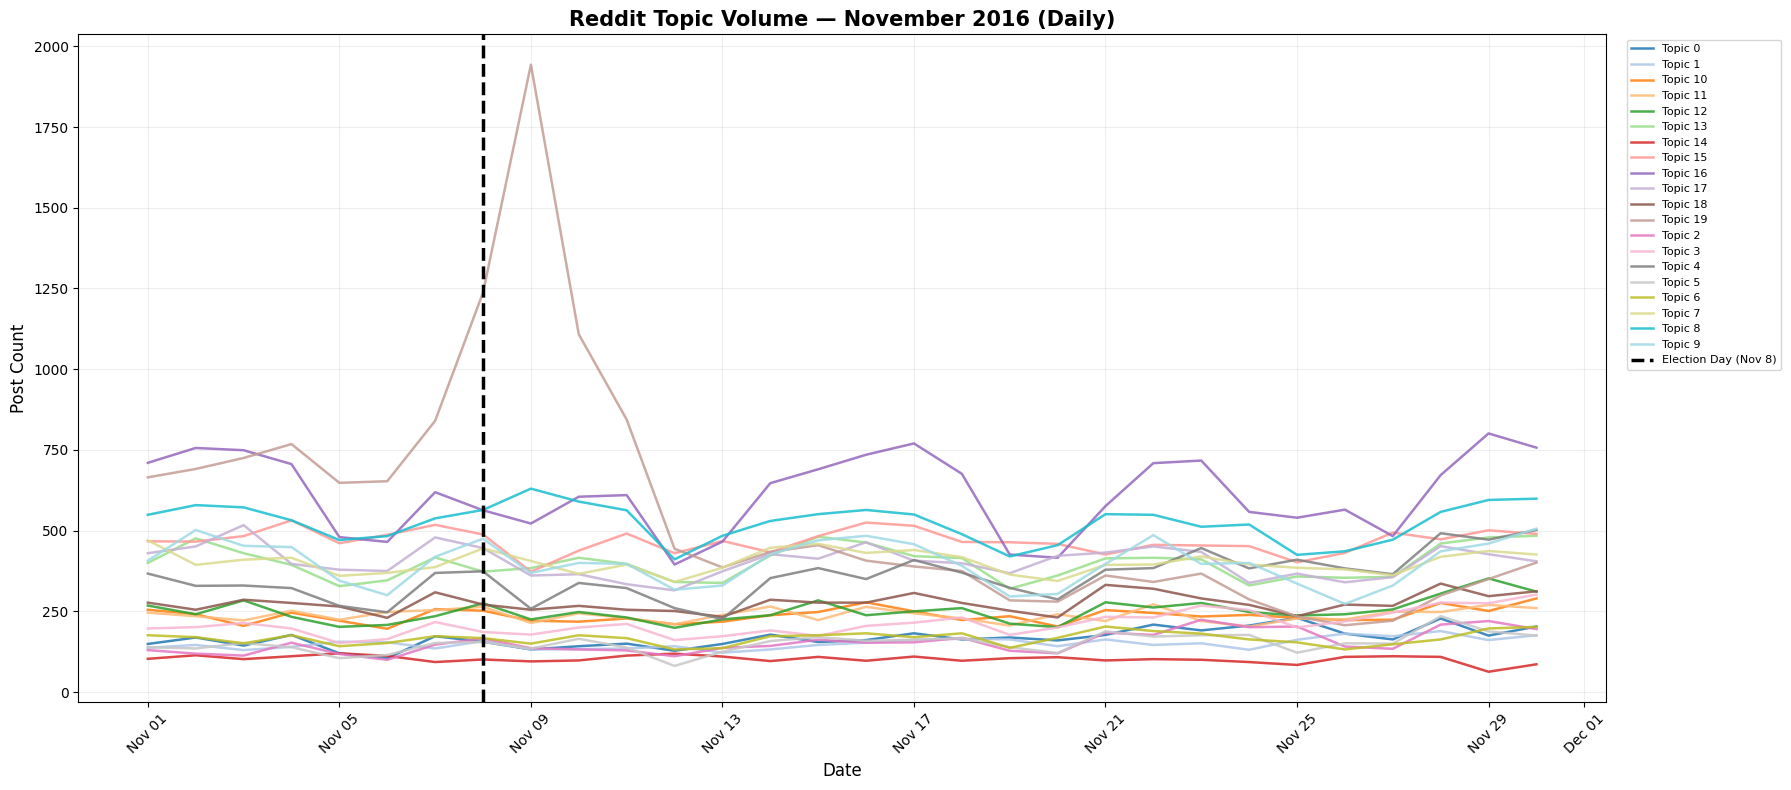

✅ Saved → ./lda_outputs/topic_trends.png


In [ ]:
topic_time = (
    df.set_index('date')
      .groupby('topic_label')
      .resample(TIME_FREQ)['id']
      .count()
      .reset_index()
      .rename(columns={'id': 'post_count'})
)

palette = sns.color_palette('tab20', n_colors=NUM_TOPICS)
fig, ax  = plt.subplots(figsize=(18, 8))

for i, (label, group) in enumerate(topic_time.groupby('topic_label')):
    ax.plot(group['date'], group['post_count'],
            label=label, color=palette[i % len(palette)],
            linewidth=1.8, alpha=0.85)

# Mark election day
ax.axvline(pd.Timestamp('2016-11-08', tz='UTC'),
           color='black', linestyle='--', linewidth=2.5, label='Election Day (Nov 8)')

ax.set_title('Reddit Topic Volume — November 2016 (Daily)', fontsize=15, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Post Count', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(True, alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/topic_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/topic_trends.png')

## STEP 14 — Spike Detection
Flags days where a topic's post volume is statistically abnormal (Z-score > 2.0).

In [ ]:
def detect_spikes(series, threshold):
    mu, sigma = series.mean(), series.std()
    if sigma == 0:
        return pd.Series(False, index=series.index)
    return (series - mu) / sigma > threshold

spike_rows = []
for label, grp in topic_time.groupby('topic_label'):
    s    = grp.sort_values('date').set_index('date')['post_count']
    mask = detect_spikes(s, SPIKE_Z_THRESHOLD)
    mu, sigma = s.mean(), s.std()
    for date, count in s[mask].items():
        spike_rows.append({
            'topic'     : label,
            'date'      : date,
            'post_count': count,
            'z_score'   : round((count - mu) / sigma, 2)
        })

spikes_df = pd.DataFrame(spike_rows).sort_values(
    'z_score', ascending=False).reset_index(drop=True)

print(f'Detected {len(spikes_df)} spike(s) at z > {SPIKE_Z_THRESHOLD}\n')
print('Top spikes:\n')
print(spikes_df.head(20).to_string(index=False))

Detected 13 spike(s) at z > 2.0

Top spikes — these should match real November 2016 events:

   topic                      date  post_count  z_score
Topic 19 2016-11-09 00:00:00+00:00        1943     3.77
Topic 12 2016-11-29 00:00:00+00:00         352     2.90
 Topic 5 2016-11-28 00:00:00+00:00         235     2.84
 Topic 3 2016-11-30 00:00:00+00:00         302     2.44
Topic 10 2016-11-30 00:00:00+00:00         290     2.38
Topic 17 2016-11-03 00:00:00+00:00         517     2.36
 Topic 1 2016-11-28 00:00:00+00:00         189     2.29
Topic 18 2016-11-28 00:00:00+00:00         336     2.13
 Topic 0 2016-11-25 00:00:00+00:00         230     2.13
 Topic 4 2016-11-30 00:00:00+00:00         502     2.11
 Topic 0 2016-11-28 00:00:00+00:00         228     2.06
 Topic 2 2016-11-23 00:00:00+00:00         224     2.05
 Topic 7 2016-11-01 00:00:00+00:00         470     2.02


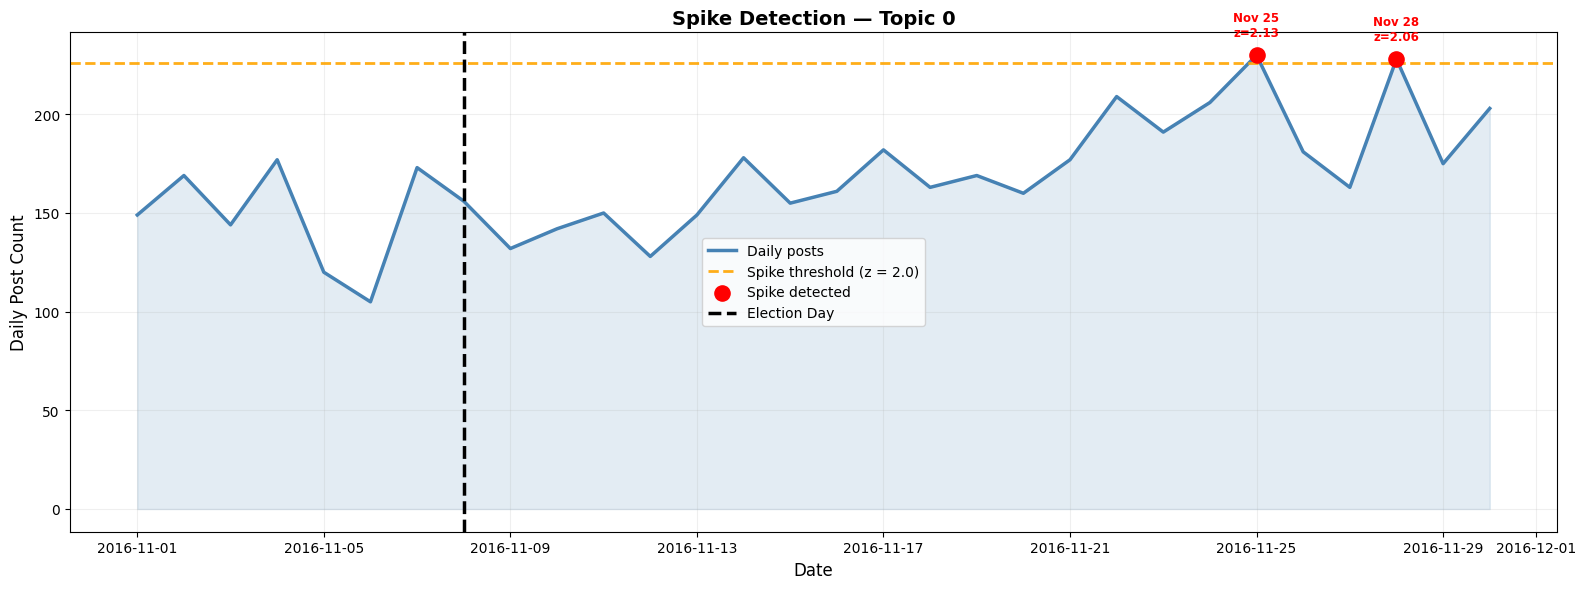

✅ Saved → ./lda_outputs/spike_detection.png


In [ ]:
# Plot spike chart — auto picks the topic with the most spikes
if len(spikes_df) > 0:
    PLOT_TOPIC = spikes_df['topic'].value_counts().index[0]
else:
    PLOT_TOPIC = df['topic_label'].value_counts().index[0]

ts     = topic_time[topic_time['topic_label'] == PLOT_TOPIC].set_index('date')['post_count']
spikes = spikes_df[spikes_df['topic'] == PLOT_TOPIC]

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(ts.index, ts.values, alpha=0.15, color='steelblue')
ax.plot(ts.index, ts.values, color='steelblue', linewidth=2.5, label='Daily posts')
ax.axhline(ts.mean() + SPIKE_Z_THRESHOLD * ts.std(),
           color='orange', linestyle='--', alpha=0.9, linewidth=2,
           label=f'Spike threshold (z = {SPIKE_Z_THRESHOLD})')
ax.scatter(spikes['date'], spikes['post_count'],
           color='red', zorder=6, s=120, label='Spike detected')
ax.axvline(pd.Timestamp('2016-11-08', tz='UTC'),
           color='black', linestyle='--', linewidth=2.5, label='Election Day')

for _, row in spikes.iterrows():
    ax.annotate(
        f"{row['date'].strftime('%b %d')}\nz={row['z_score']}",
        xy=(row['date'], row['post_count']),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=8.5, color='red', fontweight='bold'
    )

ax.set_title(f'Spike Detection — {PLOT_TOPIC}', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Post Count', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/spike_detection.png', dpi=150)
plt.show()
print(f'Saved → {OUTPUT_DIR}/spike_detection.png')

## STEP 15 — Topic Word Heatmap

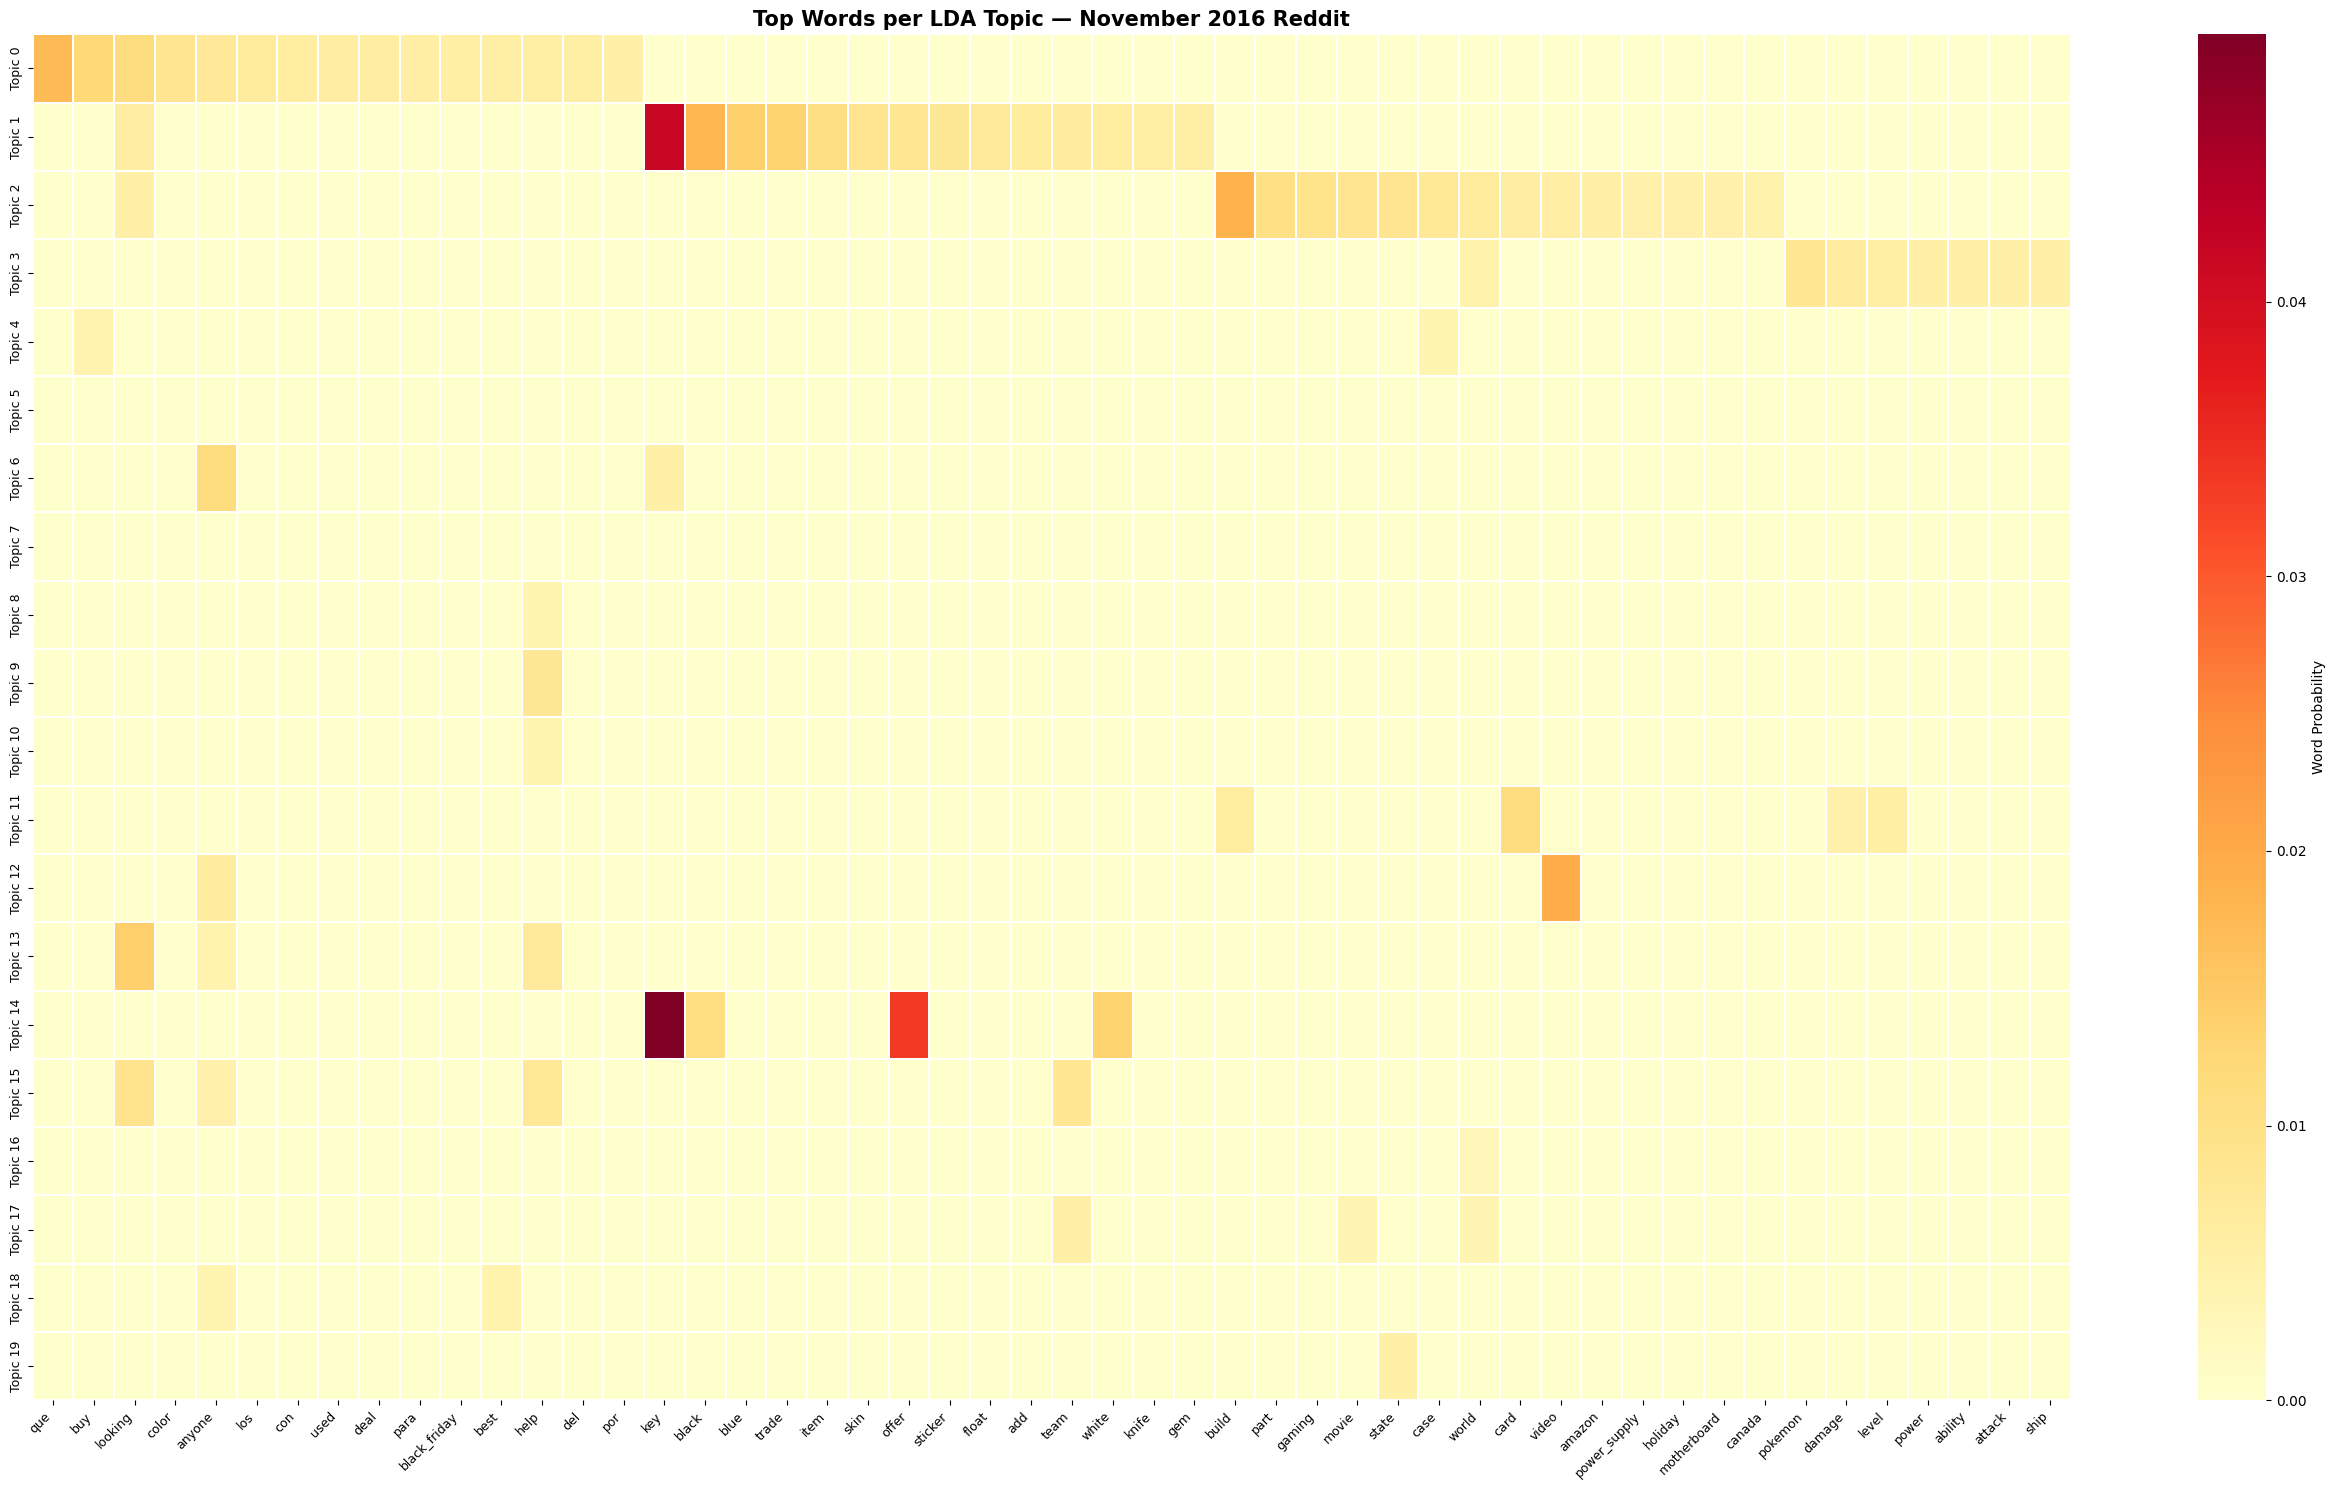

✅ Saved → ./lda_outputs/topic_word_heatmap.png


In [ ]:
TOP_N = 15   # More words per topic since we have more topics
rows, all_words = [], []
for tid in range(NUM_TOPICS):
    word_probs = lda_model.show_topic(tid, topn=TOP_N)
    rows.append({w: p for w, p in word_probs})
    all_words.extend([w for w, _ in word_probs])

unique_words = list(dict.fromkeys(all_words))
heat_df = (
    pd.DataFrame(rows, index=[TOPIC_LABELS[i] for i in range(NUM_TOPICS)])
      .fillna(0)[unique_words[:50]]
)

fig, ax = plt.subplots(figsize=(26, NUM_TOPICS * 0.65 + 2))
sns.heatmap(heat_df, cmap='YlOrRd', linewidths=0.3,
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Word Probability'}, ax=ax)
ax.set_title('Top Words per LDA Topic — November 2016 Reddit',
             fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/topic_word_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPUT_DIR}/topic_word_heatmap.png')

## STEP 16 — Sample Posts Per Topic (Verify Labels)

In [19]:
N_SAMPLES = 3
for tid in range(NUM_TOPICS):
    label  = TOPIC_LABELS[tid]
    sample = (
        df[df['dominant_topic'] == tid]
        .nlargest(N_SAMPLES, 'topic_probability')
    )
    print(f'\n{"─" * 70}')
    print(f'Topic {tid:02d}: {label}')
    print('Top words: ' + ', '.join(w for w, _ in lda_model.show_topic(tid, topn=10)))
    print('─' * 70)
    for _, row in sample.iterrows():
        print(f'  [{row["subreddit"]}] [{row["score"]} pts] {row["text"][:250]}')


──────────────────────────────────────────────────────────────────────
Topic 00: Topic 0
Top words: que, buy, looking, color, anyone, los, con, used, deal, para
──────────────────────────────────────────────────────────────────────
  [AnimalRights] [1 pts] es comer carne un pecado o una violacin tica egregiosa revisin 20  ltima actualizacin el 8 de diciembre de 2016 con muchas adiciones  mejorasprinter friendly color graphics version in english versin de impresora  color grfica en espaol se esperara un
  [podemos] [64 pts] pablo echenique si ponemos el listn donde se ha puesto con espinar dimitira todo el congreso ningn derecho social se ha ganado en los parlamentos todos se han ganado en la calle esa lgica que dice que se va a pasar mal unos aos hasta que el pas remon
  [podemos] [17 pts] una pgina desconocida de la historia de espaa el mayor desastre naval de la historia de inglaterra la contrarmada inglesa 2a parte y final                                 ataque a lisboa el siguient

In [21]:
print('=== YOUR DISCOVERED TOPICS ===\n')
for tid in range(NUM_TOPICS):
    words = lda_model.show_topic(tid, topn=10)
    top_words = ', '.join(w for w, _ in words)
    count = len(df[df['dominant_topic'] == tid])
    print(f'Topic {tid:02d} ({count:,} posts)')
    print(f'  Words: {top_words}')
    print()

=== YOUR DISCOVERED TOPICS ===

Topic 00 (5,025 posts)
  Words: que, buy, looking, color, anyone, los, con, used, deal, para

Topic 01 (4,516 posts)
  Words: key, black, blue, trade, item, skin, offer, sticker, float, add

Topic 02 (4,607 posts)
  Words: build, part, gaming, movie, state, case, world, card, video, looking

Topic 03 (6,349 posts)
  Words: pokemon, damage, level, power, ability, attack, ship, world, ball, enemy

Topic 04 (10,701 posts)
  Words: car, free, price, store, sale, shipping, order, service, gold, buy

Topic 05 (4,546 posts)
  Words: episode, die, host, star, ford, der, arnold, theory, und, scene

Topic 06 (4,988 posts)
  Words: job, anyone, ive, interview, class, question, dont, found, guy, key

Topic 07 (12,060 posts)
  Words: around, dog, night, didnt, eye, hand, room, went, face, man

Topic 08 (15,741 posts)
  Words: dont, feel, ive, life, thing, something, friend, cant, didnt, week

Topic 09 (12,014 posts)
  Words: help, question, work, using, please, user,

## STEP 17 — Save All Outputs

In [ ]:
out_cols = ['id', 'subreddit', 'author', 'date', 'score',
            'num_comments', 'text', 'dominant_topic',
            'topic_probability', 'topic_label']

df[out_cols].to_csv(f'{OUTPUT_DIR}/posts_with_topics.csv',  index=False)
topic_time.to_csv(f'{OUTPUT_DIR}/topic_time_series.csv',    index=False)
spikes_df.to_csv(f'{OUTPUT_DIR}/spike_report.csv',          index=False)

print(f'All outputs saved to: {OUTPUT_DIR}/')
print()

import os
outputs = [
    ('posts_with_topics.csv',   'Every post tagged with its dominant LDA topic'),
    ('topic_time_series.csv',   'Daily post count per topic'),
    ('spike_report.csv',        'Detected spike dates with z-scores'),
    ('lda_visualization.html',  'Interactive pyLDAvis — open in browser'),
    ('eda_overview.png',        'EDA: posts per day, top subreddits, scores'),
    ('coherence_sweep.png',     'Coherence score vs number of topics'),
    ('topic_trends.png',        'Topic volume over time with election day marker'),
    ('topic_word_heatmap.png',  'Heatmap of top words per topic'),
    ('spike_detection.png',     'Spike detection chart with annotations'),
    ('lda_model',               'Saved Gensim model — reload without retraining'),
]

for fname, desc in outputs:
    path = f'{OUTPUT_DIR}/{fname}'
    exists = 'X' if os.path.exists(path) else '?'
    print(f'  {exists}  {fname:<35} {desc}')

✅ All outputs saved to: ./lda_outputs/

  ✅  posts_with_topics.csv               Every post tagged with its dominant LDA topic
  ✅  topic_time_series.csv               Daily post count per topic
  ✅  spike_report.csv                    Detected spike dates with z-scores
  ✅  lda_visualization.html              Interactive pyLDAvis — open in browser
  ✅  eda_overview.png                    EDA: posts per day, top subreddits, scores
  ✅  coherence_sweep.png                 Coherence score vs number of topics
  ✅  topic_trends.png                    Topic volume over time with election day marker
  ✅  topic_word_heatmap.png              Heatmap of top words per topic
  ✅  spike_detection.png                 Spike detection chart with annotations
  ✅  lda_model                           Saved Gensim model — reload without retraining


## STEP 18 — Reload Saved Model (Skip Retraining)
Run this cell in future sessions to pick up right where you left off.

In [ ]:
# Uncomment and run this block to reload everything without retraining

# from gensim.models import LdaMulticore
# from gensim import corpora
# import pandas as pd

# OUTPUT_DIR = './lda_outputs'

# lda_model  = LdaMulticore.load(f'{OUTPUT_DIR}/lda_model')
# dictionary = corpora.Dictionary.load(f'{OUTPUT_DIR}/lda_dictionary')
# corpus     = list(corpora.MmCorpus(f'{OUTPUT_DIR}/lda_corpus.mm'))
# df         = pd.read_pickle(f'{OUTPUT_DIR}/df_checkpoint.pkl')

# print(f'✅ Reloaded!')
# print(f'   Posts  : {len(df):,}')
# print(f'   Topics : {lda_model.num_topics}')